In [1]:
import numpy as np
import pandas as pd

from rlbench.action_modes.action_mode import MoveArmThenGripper
from rlbench.action_modes.arm_action_modes import JointVelocity
from rlbench.action_modes.gripper_action_modes import Discrete
from rlbench.environment import Environment
from rlbench.observation_config import ObservationConfig, CameraConfig
from rlbench.task_environment import TaskEnvironment


from rlbench.backend.observation import Observation
from rlbench.demo import Demo

from pyrep.const import RenderMode
from pyrep.objects import Object

import numpy as np
import torch
import torch.nn.functional as F

from policy import Policy, Agent, CamType

import matplotlib.pyplot as plt


from utils import set_seed

##Tasks  
from rlbench.tasks.reach_target_no_obs_central import ReachTargetNoObsCentral as Central
from rlbench.tasks.reach_target_no_obs_side_r import ReachTargetNoObsSideR as SideR
from rlbench.tasks.reach_target_no_obs_side_l import ReachTargetNoObsSideL as SideL

from rlbench.tasks.reach_target_no_obs import ReachTargetNoObs as PlaceRandom

set_seed(42)


## Environment Launch


In [2]:

cam_type = CamType.WRIST

live_demos = True
DATASET = '' if live_demos else 'PATH/TO/YOUR/DATASET'

obs_config = ObservationConfig()
obs_config.set_all(True) ## important to get the data from the joints etc
cam_config = CameraConfig(rgb=True, depth=False, mask=False,
                              render_mode=RenderMode.OPENGL,
                    image_size=(64, 64))
nocam_config = CameraConfig(rgb=False, depth=False, mask=False,
                          render_mode=RenderMode.OPENGL)

obs_config.right_shoulder_camera = cam_config
obs_config.left_shoulder_camera = cam_config
obs_config.overhead_camera = nocam_config
obs_config.front_camera = nocam_config

## active camera: wrist camera
obs_config.wrist_camera = cam_config


action_mode = MoveArmThenGripper(
    arm_action_mode=JointVelocity(), gripper_action_mode=Discrete())

env = Environment(
    action_mode, DATASET, obs_config, False)
env.launch()





## Helper Functions to be used later


In [6]:
def get_task_name(task) -> str:
  if task == Central:
    return "Central"
  elif task == SideL:
    return "Side Left"
  elif task == SideR:
    return "Side Right"
  elif task == PlaceRandom:
    return "Place Random"
  else:
    raise ValueError("[get_task_name] Task not found!")

## 
def request_demos_and_train_for_task(current_task, agent: Agent, num_demos: int,  save_model = False, **training_params) -> TaskEnvironment:
  task_name = get_task_name(current_task) 
  
  ## load this task into env
  task_env = env.get_task(current_task) # removes all other loaded tasks
  ## num_demos defined in the 
  demos: list[Demo] = task_env.get_demos(num_demos, live_demos=live_demos)
  agent.ingest(demos, **training_params)
  if save_model:
    model_name = f"task-{task_name}-{num_demos}-demo-{cam_type}"
    model_path = f"./models/{model_name}.pth"
    agent.save_model(model_path)
  
  return task_env

def run_task(
  env: Environment,
  task,
  cam_type: CamType,
  demo_count: int,
  max_eplen: int = 100,
  **training_params
) -> list[float]:
  print(f"Training for {demo_count} demos for task: {get_task_name(task)}")
  ## new agent trained each time
  agent = Agent(env.action_shape[0], cam_type)
  
  ## request demos and train
  task_env = request_demos_and_train_for_task(
    task,
    agent,
    demo_count,
    save_model=True,
    **training_params
  )
  
  ## evaluate
  obs: Observation
  _, obs = task_env.reset()
  agent.policy.to("cpu") # move to cpu
  distances = []
  
  for _ in range(max_eplen):
    action = agent.act(obs).squeeze()
    obs, reward, done = task_env.step(action)

    gripper = Object.get_object("Panda_gripper")
    target = Object.get_object("target")
    distance = np.linalg.norm(gripper.get_position() - target.get_position())
    distances.append(distance)
    if done:
      break
    
  return distances

- For each task, the episode length (number of frames captuures) is ~50, therefore will give the system 80 steps
- second set of graphs allow it to go up to 300

In [4]:
max_eplen = 100 ## tried 80 first, see if there is a difference

from pprint import pprint
repeats = 10
tasks = [Central, SideR, SideL]
demo_counts = [1, 2, 5, 10]

## HyperParam Search
as the number of demo frames I have are low, I am going to try higher learning rates, see how that affects learning

Doing thisn because the side[l/r] performs very badly for one demonstration, so the network must not be optimal

In [5]:
from itertools import product
params = {
  "epochs": [100, 200],
  "minibatch_size": [16, 32],
  "lr": [0.01, 0.005, 0.0025]
}

max_eplen = 100
repeats = 1

demo_count = 1
## do for 1 demo see the differces
results = {}
for epoch, mb_size,lr  in product(params["epochs"], params["minibatch_size"], params["lr"]):
  final_dists_avg = {task: 0 for task in tasks}
  min_dists_avg = {task: 0 for task in tasks}
  for task in tasks:
    for i in range(repeats):
      distances = run_task(env, task, cam_type, demo_count, max_eplen, epochs=epoch, minibatch_size=mb_size, lr=lr)
      final_dists_avg[task] += distances[-1]    
      min_dists_avg[task] += min(distances)
      
    results[(epoch, mb_size, lr, task)] = {
        "final_dists": final_dists_avg[task]  / repeats,
        "min_dists": min_dists_avg[task] / repeats
    }
    
print("Done")

Training for 1 demos for task: Central
Training Params: 
	epochs = 100, 
	minibatch_size = 16, 
	lr = 0.01, 
	model_path = None, 
	cuda



100%|██████████| 100/100 [00:00<00:00, 134.24it/s]


Done Training Policy on 1 Demos
Saved Model under './models/task-Central-1-demo-wrist.pth'
Training for 1 demos for task: Side Right
Training Params: 
	epochs = 100, 
	minibatch_size = 16, 
	lr = 0.01, 
	model_path = None, 
	cuda



100%|██████████| 100/100 [00:00<00:00, 176.53it/s]


Done Training Policy on 1 Demos
Saved Model under './models/task-Side Right-1-demo-wrist.pth'
Training for 1 demos for task: Side Left
Training Params: 
	epochs = 100, 
	minibatch_size = 16, 
	lr = 0.01, 
	model_path = None, 
	cuda



...

Done Training Policy on 1 Demos
Saved Model under './models/task-Central-1-demo-wrist.pth'
Training for 1 demos for task: Side Right
Training Params: 
	epochs = 200, 
	minibatch_size = 32, 
	lr = 0.0025, 
	model_path = None, 
	cuda



100%|██████████| 200/200 [00:00<00:00, 271.43it/s]


Done Training Policy on 1 Demos
Saved Model under './models/task-Side Right-1-demo-wrist.pth'
Training for 1 demos for task: Side Left
Training Params: 
	epochs = 200, 
	minibatch_size = 32, 
	lr = 0.0025, 
	model_path = None, 
	cuda



100%|██████████| 200/200 [00:00<00:00, 263.43it/s]


Done Training Policy on 1 Demos
Saved Model under './models/task-Side Left-1-demo-wrist.pth'
Done


In [14]:
# import pandas as pd
# data = []
# for (e, mb, lr, task), metrics in results.items():
#   data.append({
#         'epoch': e,
#         'minibatch_size': mb,
#         'learning_rate': lr,
#         'taskname': get_task_name(task),
#         'final_dist': metrics['final_dists'],
#         'min_dist': metrics['min_dists']
#     })

# # Create a DataFrame
# df = pd.DataFrame(data)
# # print(df)
# df.to_csv("results.csv", index=False)
df = pd.read_csv("results.csv")

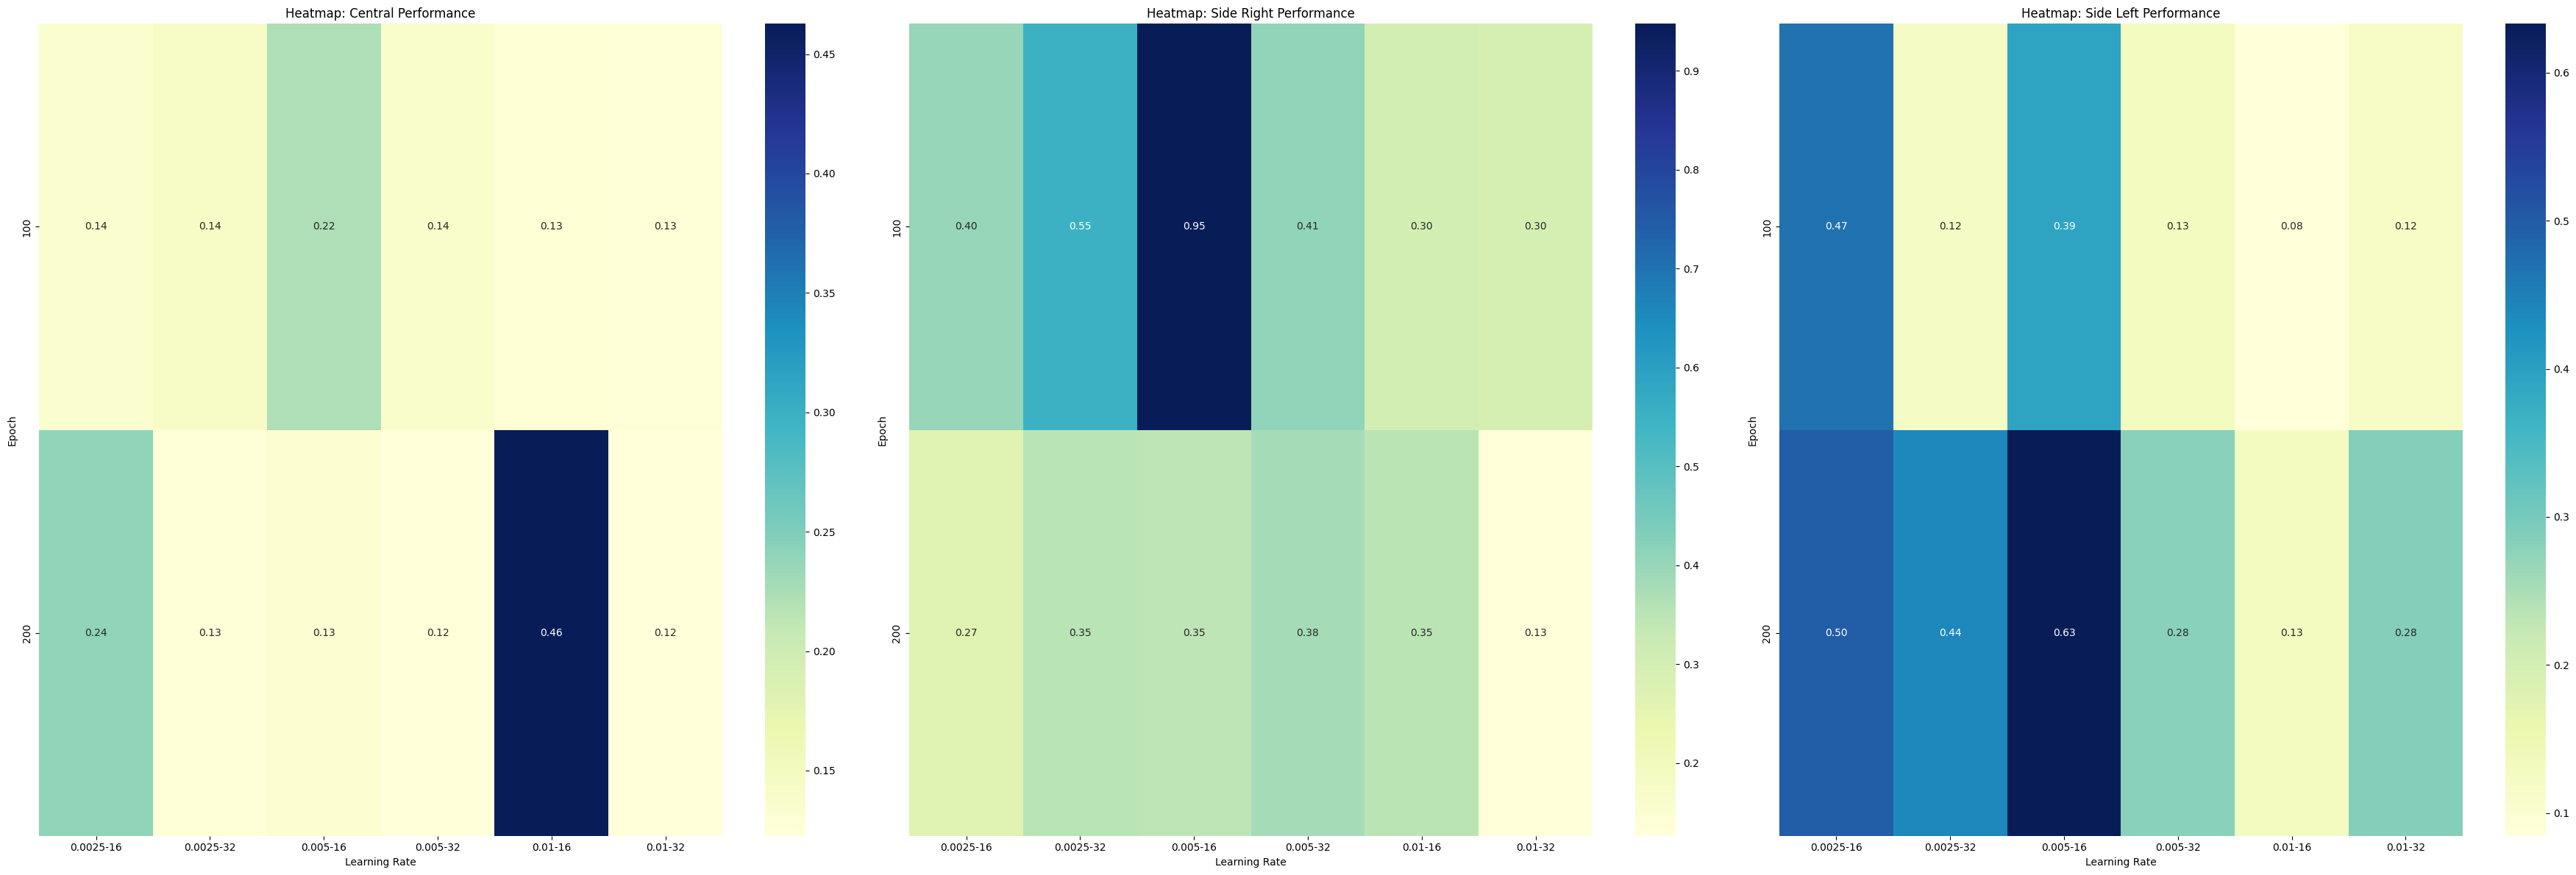

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of task names


# Create a figure with subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(36, 12))

# Loop through each task to create a pivot table and plot
for i, task in enumerate(tasks):
    task = get_task_name(task)  # Get the task name for the current task
    # Filter the data for the current task
    task_data = df[df['taskname'] == task]

    # Pivot the data for the current task
    heatmap_data = task_data.pivot_table(index='epoch', columns=['learning_rate', "minibatch_size"], values='final_dist', aggfunc='mean')

    # Check if there are any NaN values, and handle them (fill with 0 or interpolate)
    heatmap_data = heatmap_data.fillna(0)  # or interpolate()

    # Plot the heatmap for the current task
    sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.2f', ax=axes[i])

    # Set the title for each subplot
    axes[i].set_title(f'Heatmap: {task} Performance')
    axes[i].set_xlabel('Learning Rate')
    axes[i].set_ylabel('Epoch')

# Adjust layout
plt.tight_layout()
plt.show()

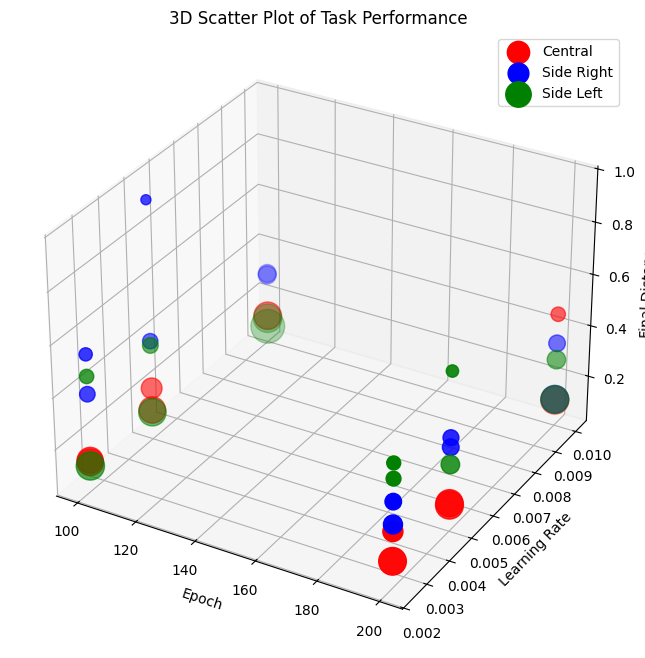

In [54]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Combine data for all tasks (assuming your data is in 'df')
df_combined = df[df['taskname'].isin(list(map(get_task_name, tasks)))]
# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Define a color palette for the tasks
task_palette = {Central: 'r', SideL: 'g', SideR: 'b'}

# Plot the data
for task in tasks:
    task_name = get_task_name(task)
    task_data = df_combined[df_combined['taskname'] == task_name]
    
    # Scatter plot for each task (epoch, learning_rate, final_dist)
    ax.scatter(
        task_data['epoch'], 
        task_data['learning_rate'], 
        task_data['final_dist'], 
        c=task_palette[task], 
        label=task_name, 
        s=50 * (1 / task_data["final_dist"]) # Size of the scatter points
    )

# Labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_zlabel('Final Distance')
ax.set_title('3D Scatter Plot of Task Performance')

# Legend
ax.legend()

# Show plot
plt.show()

In [38]:
import plotly.express as px

# Parallel coordinates plot
fig = px.parallel_coordinates(
    df, 
    color='final_dist', 
    labels={
        'epoch': 'Epoch', 
        'minibatch_size': 'Minibatch Size', 
        'learning_rate': 'Learning Rate', 
        'final_dist': 'Final Distance'
    },
    dimensions=['epoch', 'minibatch_size', 'learning_rate', 'final_dist']
)

fig.show()

In [ ]:
import plotly.graph_objects as go
import plotly.subplots as sp

colours =  plt.cm.viridis(np.linspace(0, 1, len(tasks)))
task_cm =  {task: colour for task, colour in zip(tasks, colours)}

colours = ['blue', 'red', 'green', 'purple', 'orange', 'cyan', 'magenta']

data = results


fig = go.Figure()

# Plot each task in the same 3D plot with different colors
for task in tasks:
  print(f"Plotting task: {get_task_name(task)}")
  epochs = [k[0] for k in data.keys() if k[3] == task]
  minibatches = [k[1] for k in data.keys() if k[3] == task]
  lrs = [k[2] for k in data.keys() if k[3] == task]
  final_dists = [data[k]['final_dists'] for k in data.keys() if k[3] == task]
  min_dists = [data[k]['min_dists'] for k in data.keys() if k[3] == task]

  # Add scatter plot for this task to the combined figure
  
  task_name = get_task_name(task)
  fig.add_trace(go.Scatter3d(
    x=epochs,
    y=minibatches,
    z=lrs,
    mode='markers',
    name=task_name,
    marker=dict(
        size=8,
        color=final_dists,  # Use final_dists for color intensity
        colorscale='Viridis',  # Color scale
        showscale=True,  # Display color scale
        colorbar=dict(title="Final Dist")
    ),
    text=[f"Task: {task_name}<br>Epochs: {ep}<br>Minibatch: {mb}<br>LR: {lr}<br>Final Dist: {fd:.4f}<br>Min Dist: {md:.4f}"
          for ep, mb, lr, fd, md in zip(epochs, minibatches, lrs, final_dists, min_dists)],
    hoverinfo='text'
  ))

# Set up labels and title
fig.update_layout(
    title="3D Hyperparameter Visualization for Multiple Tasks",
    scene=dict(
        xaxis_title='Epochs',
        yaxis_title='Minibatch Size',
        zaxis_title='Learning Rate',
        zaxis_type='log'  # Log scale for learning rate (optional)
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

# Show interactive plot
fig.show()

Plotting task: Central
Plotting task: Side Right
Plotting task: Side Left


## Running the Tasks with found Params

After searching, the best ones I found are (not an amazing way to visualise these) [epochs, mb_size, lr]

- 200, 32, 0.01; good with min_dist, very decent with final max around 0.3.
- 100, 16/32, 0.01; not as good as above, but consistent with all, batch size doesn't seem to be a big concern here
- Check the images saved in assets if others are needed

In [21]:
results = [{
  task: {
    demo_count: {"min_dist": None, "final_dist": None}
    for demo_count in demo_counts
    
  }
  for task in tasks
} for _ in range(repeats)]

## params to try
params = {
  "epochs": 200,
  "minibatch_size": 32, 
  "lr": 0.01
}

for i in range(repeats):
  for task in tasks:
    for demo_count in demo_counts:
      distances = run_task(env, task, cam_type, demo_count, max_eplen, **params)
      
      results[i][task][demo_count]["min_dist"] = min(distances)
      results[i][task][demo_count]["final_dist"] = distances[-1]
      


Training for 1 demos for task: Central
Training Params: 
	epochs = 200, 
	minibatch_size = 32, 
	lr = 0.01, 
	model_path = None, 
	cuda



100%|██████████| 200/200 [00:00<00:00, 258.63it/s]


Done Training Policy on 1 Demos
Saved Model under './models/task-Central-1-demo-wrist.pth'
Training for 2 demos for task: Central
Training Params: 
	epochs = 200, 
	minibatch_size = 32, 
	lr = 0.01, 
	model_path = None, 
	cuda



100%|██████████| 200/200 [00:01<00:00, 134.74it/s]


Done Training Policy on 2 Demos
Saved Model under './models/task-Central-2-demo-wrist.pth'
Training for 5 demos for task: Central
Training Params: 
	epochs = 200, 
	minibatch_size = 32, 
	lr = 0.01, 
	model_path = None, 
	cuda



...

Done Training Policy on 2 Demos
Saved Model under './models/task-Side Left-2-demo-wrist.pth'
Training for 5 demos for task: Side Left
Training Params: 
	epochs = 200, 
	minibatch_size = 32, 
	lr = 0.01, 
	model_path = None, 
	cuda



100%|██████████| 200/200 [00:03<00:00, 55.63it/s]


Done Training Policy on 5 Demos
Saved Model under './models/task-Side Left-5-demo-wrist.pth'
Training for 10 demos for task: Side Left
Training Params: 
	epochs = 200, 
	minibatch_size = 32, 
	lr = 0.01, 
	model_path = None, 
	cuda



100%|██████████| 200/200 [00:06<00:00, 28.85it/s]


Done Training Policy on 10 Demos
Saved Model under './models/task-Side Left-10-demo-wrist.pth'


## Plot the 10 Runs
- 10 individual runs to see the differences
- Final averaged distance to goal

> Note: Running with extra leeway in episode length, (tried 80, 100, 300) doesn't change anything, because the demos are ~50, and a successful policy completes it around that time, longer allowance confuses the system

- the distance is taken from the centre of the object and the radius is about 0.12, this means any distance ~.12 is actually reaching the object. This can be fixed on the graphs by a simple translation so I left it in


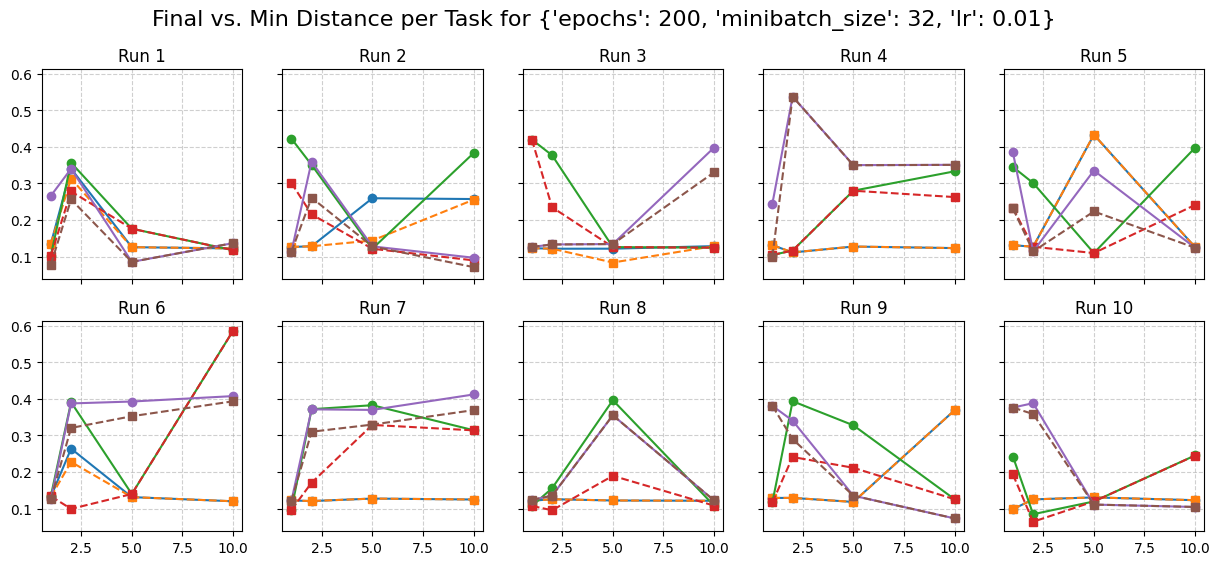

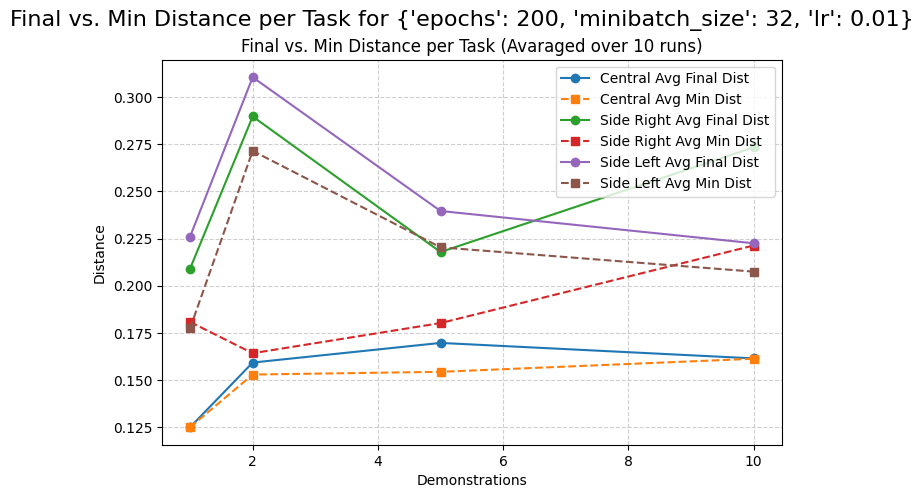

In [25]:
## Original, episode length allowed = 80

# Extracting tasks and distances
tasks = list(results[0].keys())

final_dists = {task: [results[0][task][demo]['final_dist'] for demo in demo_counts] for task in tasks}
min_dists = {task: [results[0][task][demo]['min_dist'] for demo in demo_counts] for task in tasks}

# Initialize figure
fig, axes = plt.subplots(2, (repeats + 1) // 2, figsize=(15, 6), sharex=True, sharey=True)
axes = axes.flatten()
fig.suptitle(f'Final vs. Min Distance per Task for {params}', fontsize=16)

# Collect data for averaging
final_dists_avg = {task: np.zeros(len(demo_counts)) for task in tasks}
min_dists_avg = {task: np.zeros(len(demo_counts)) for task in tasks}

# Plot individual runs
for run_idx in range(repeats):
  for task in tasks:
    task_name = get_task_name(task)
    final_dists = [results[run_idx][task][demo]['final_dist'] for demo in demo_counts]
    min_dists = [results[run_idx][task][demo]['min_dist'] for demo in demo_counts]
    
    final_dists_avg[task] += np.array(final_dists)
    min_dists_avg[task] += np.array(min_dists)
    
    axes[run_idx].plot(demo_counts, final_dists, marker='o', linestyle='-', label=f'{task_name} Final Dist')
    axes[run_idx].plot(demo_counts, min_dists, marker='s', linestyle='--', label=f'{task_name} Min Dist')
  
  axes[run_idx].set_title(f'Run {run_idx+1}')
  axes[run_idx].grid(True, linestyle='--', alpha=0.6)
    

# Average the distances
total_runs = 10
for task in tasks:
  final_dists_avg[task] /= total_runs
  min_dists_avg[task] /= total_runs

# Create an averaged graph
plt.figure(figsize=(8, 5))
for task in tasks:
  task_name = get_task_name(task)
  plt.plot(demo_counts, final_dists_avg[task], marker='o', linestyle='-', label=f'{task_name} Avg Final Dist')
  plt.plot(demo_counts, min_dists_avg[task], marker='s', linestyle='--', label=f'{task_name} Avg Min Dist')
    
plt.suptitle(f'Final vs. Min Distance per Task for {params}', fontsize=16)
plt.xlabel('Demonstrations')
plt.ylabel('Distance')
plt.title(f'Final vs. Min Distance per Task (Avaraged over {repeats} runs)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

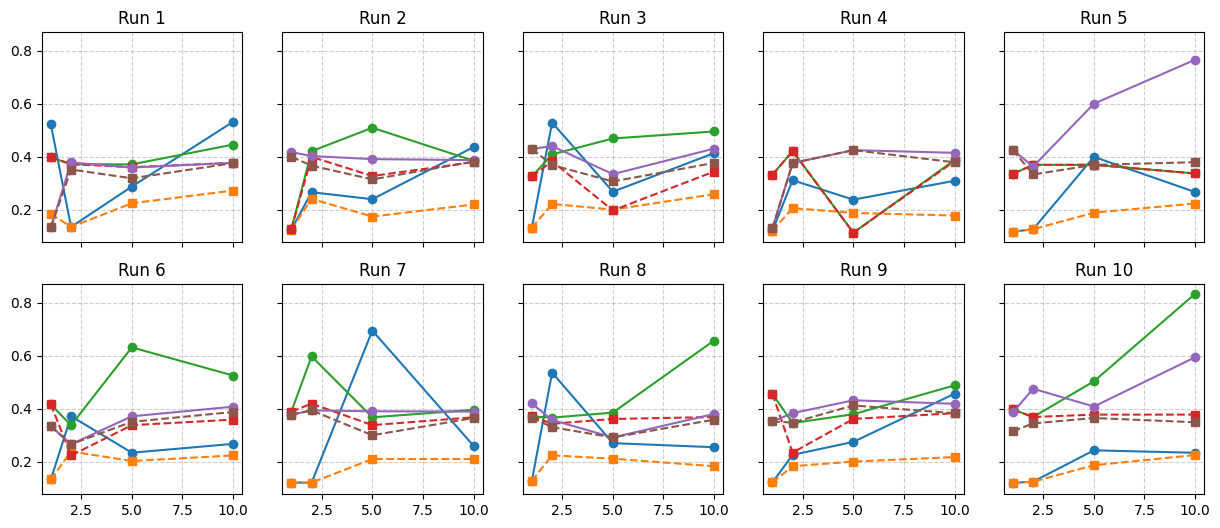

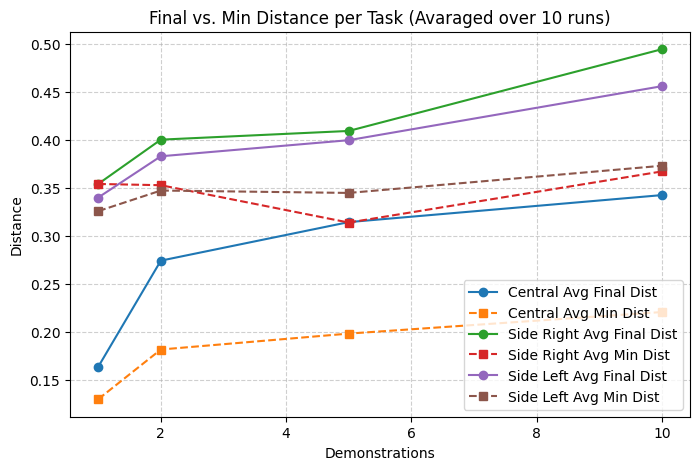

In [ ]:
## More Leeway, max episode length is 300

# Extracting tasks and distances
tasks = list(results[0].keys())

final_dists = {task: [results[0][task][demo]['final_dist'] for demo in demo_counts] for task in tasks}
min_dists = {task: [results[0][task][demo]['min_dist'] for demo in demo_counts] for task in tasks}

# Initialize figure
fig, axes = plt.subplots(2, (repeats + 1) // 2, figsize=(15, 6), sharex=True, sharey=True)
axes = axes.flatten()

# Collect data for averaging
final_dists_avg = {task: np.zeros(len(demo_counts)) for task in tasks}
min_dists_avg = {task: np.zeros(len(demo_counts)) for task in tasks}

# Plot individual runs
for run_idx in range(repeats):
  for task in tasks:
    task_name = get_task_name(task)
    final_dists = [results[run_idx][task][demo]['final_dist'] for demo in demo_counts]
    min_dists = [results[run_idx][task][demo]['min_dist'] for demo in demo_counts]
    
    final_dists_avg[task] += np.array(final_dists)
    min_dists_avg[task] += np.array(min_dists)
    
    axes[run_idx].plot(demo_counts, final_dists, marker='o', linestyle='-', label=f'{task_name} Final Dist')
    axes[run_idx].plot(demo_counts, min_dists, marker='s', linestyle='--', label=f'{task_name} Min Dist')
  
  axes[run_idx].set_title(f'Run {run_idx+1}')
  axes[run_idx].grid(True, linestyle='--', alpha=0.6)
    

# Average the distances
total_runs = 10
for task in tasks:
  final_dists_avg[task] /= total_runs
  min_dists_avg[task] /= total_runs

# Create an averaged graph
plt.figure(figsize=(8, 5))
for task in tasks:
  task_name = get_task_name(task)
  plt.plot(demo_counts, final_dists_avg[task], marker='o', linestyle='-', label=f'{task_name} Avg Final Dist')
  plt.plot(demo_counts, min_dists_avg[task], marker='s', linestyle='--', label=f'{task_name} Avg Min Dist')
    
    
plt.xlabel('Demonstrations')
plt.ylabel('Distance')
plt.title(f'Final vs. Min Distance per Task (Avaraged over {repeats} runs)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [6]:
df = pd.read_csv("results.csv")

df.sort_values(by = "final_dist", ascending=True)



,epoch,minibatch_size,learning_rate,taskname,final_dist,min_dist
2,100,16,0.0100,Side Left,0.084523,0.084523
11,100,32,0.0100,Side Left,0.118178,0.118178
17,100,32,0.0025,Side Left,0.121078,0.121078
27,200,32,0.0100,Central,0.122658,0.122658
30,200,32,0.0050,Central,0.123703,0.123703
20,200,16,0.0100,Side Left,0.125362,0.125362
28,200,32,0.0100,Side Right,0.126354,0.126354
33,200,32,0.0025,Central,0.126502,0.126502
9,100,32,0.0100,Central,0.127818,0.127818
14,100,32,0.0050,Side Left,0.128014,0.128014


## Randomly Moving Target

I am going to stop doing min_dist as this seems to bot  be very useful, I will just shorten the epiode length and see if we can get the arm close

> Random placement around max 66 eplen to reach something from tests, so will cap it at 75 to see where we get to


In [8]:
from itertools import product
params = {
  "epochs": [100, 150, 200, 300],
  "minibatch_size": [16, 32],
  "lr": [0.01, 0.005, 0.0025],
  "demos": [1, 2, 5, 10]
}

max_eplen = 75
repeats = 10


results = {}
for epoch, mb_size, lr, demo_count  in product(params["epochs"], params["minibatch_size"], params["lr"], params["demos"]):
  final_dists_avg = 0
  for i in range(repeats):
    distances = run_task(env, PlaceRandom, cam_type, demo_count, max_eplen, epochs=epoch, minibatch_size=mb_size, lr=lr)
    final_dists_avg += distances[-1]    ## only doing final distancce at end of episode
    # min_dists_avg[task] += min(distances)
      
  results[(epoch, mb_size, lr, demo_count)] = {
    "final_dist": final_dists_avg  / repeats,
  }
    
print("Done")


Training for 1 demos for task: Place Random
Training Params: 
	epochs = 100, 
	minibatch_size = 16, 
	lr = 0.01, 
	model_path = None, 
	cuda



100%|██████████| 100/100 [00:00<00:00, 213.10it/s]


Done Training Policy on 1 Demos
Saved Model under './models/task-Place Random-1-demo-wrist.pth'
Training for 1 demos for task: Place Random
Training Params: 
	epochs = 100, 
	minibatch_size = 16, 
	lr = 0.01, 
	model_path = None, 
	cuda



100%|██████████| 100/100 [00:00<00:00, 212.96it/s]


Done Training Policy on 1 Demos
Saved Model under './models/task-Place Random-1-demo-wrist.pth'
Training for 1 demos for task: Place Random
Training Params: 
	epochs = 100, 
	minibatch_size = 16, 
	lr = 0.01, 
	model_path = None, 
	cuda



...

Done Training Policy on 10 Demos
Saved Model under './models/task-Place Random-10-demo-wrist.pth'
Training for 10 demos for task: Place Random
Training Params: 
	epochs = 300, 
	minibatch_size = 32, 
	lr = 0.0025, 
	model_path = None, 
	cuda



100%|██████████| 300/300 [00:08<00:00, 34.73it/s]


Done Training Policy on 10 Demos
Saved Model under './models/task-Place Random-10-demo-wrist.pth'
Training for 10 demos for task: Place Random
Training Params: 
	epochs = 300, 
	minibatch_size = 32, 
	lr = 0.0025, 
	model_path = None, 
	cuda



100%|██████████| 300/300 [00:08<00:00, 35.03it/s]


Done Training Policy on 10 Demos
Saved Model under './models/task-Place Random-10-demo-wrist.pth'
Done


In [9]:
pprint(results, indent=2)

{ (100, 16, 0.0025, 1): {'final_dist': np.float64(0.4613889265833867)},
  (100, 16, 0.0025, 2): {'final_dist': np.float64(0.4355148621444811)},
  (100, 16, 0.0025, 5): {'final_dist': np.float64(0.23835526144269287)},
  (100, 16, 0.0025, 10): {'final_dist': np.float64(0.23793504875975602)},
  (100, 16, 0.005, 1): {'final_dist': np.float64(0.2809874116126013)},
  (100, 16, 0.005, 2): {'final_dist': np.float64(0.20028177501660727)},
  (100, 16, 0.005, 5): {'final_dist': np.float64(0.31797009593444464)},
  (100, 16, 0.005, 10): {'final_dist': np.float64(0.18472252206815512)},
  (100, 16, 0.01, 1): {'final_dist': np.float64(0.24578344932019108)},
  (100, 16, 0.01, 2): {'final_dist': np.float64(0.24310536116307097)},
  (100, 16, 0.01, 5): {'final_dist': np.float64(0.24576186003316308)},
  (100, 16, 0.01, 10): {'final_dist': np.float64(0.10417033767558023)},
  (100, 32, 0.0025, 1): {'final_dist': np.float64(0.4778191683666848)},
  (100, 32, 0.0025, 2): {'final_dist': np.float64(0.513914814939

In [30]:
df = pd.DataFrame.from_dict(results, orient='index')

df.index = pd.MultiIndex.from_tuples(df.index, names=["epoch", "minibatch_size", "learning_rate", "demo_count"])
df.reset_index(inplace=True)
df

,epoch,minibatch_size,learning_rate,demo_count,final_dist
0,100,16,0.0100,1,0.245783
1,100,16,0.0100,2,0.243105
2,100,16,0.0100,5,0.245762
3,100,16,0.0100,10,0.104170
4,100,16,0.0050,1,0.280987
...,...,...,...,...,...
91,300,32,0.0050,10,0.201507
92,300,32,0.0025,1,0.238372
93,300,32,0.0025,2,0.266005
94,300,32,0.0025,5,0.282567


## HyperParam Heatmap 

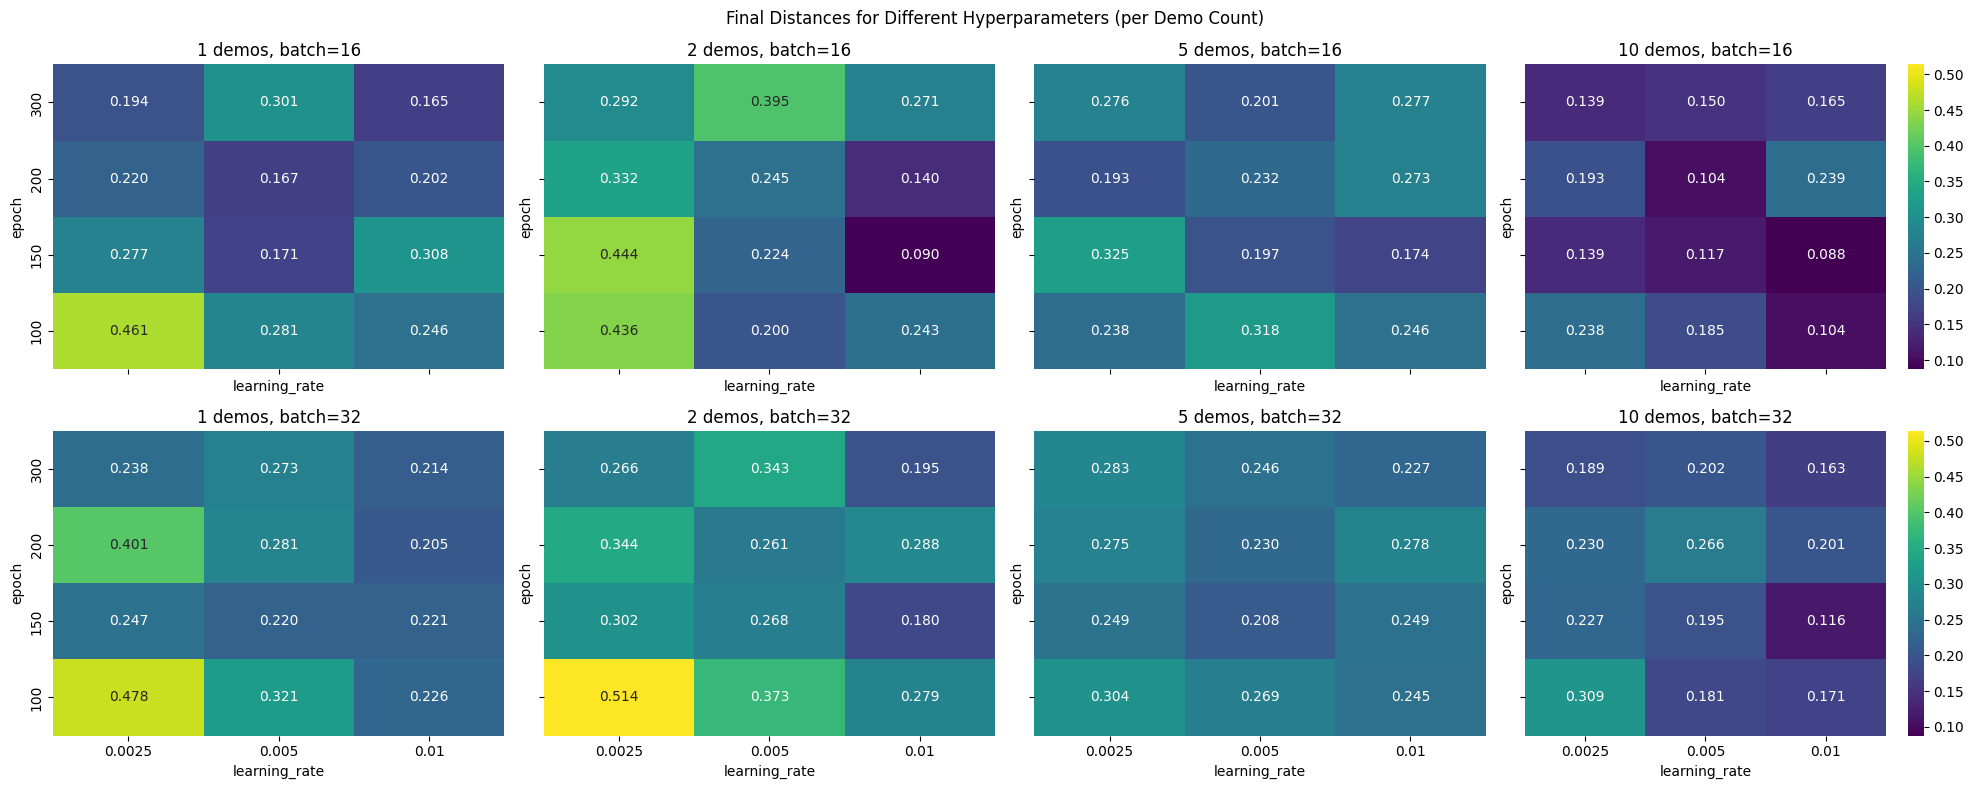

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product


# Convert to DataFrame

# Set up plot
fig, axs = plt.subplots(2, 4, figsize=(20, 8), sharex = True, sharey=True)
vmin = df['final_dist'].min()
vmax = df['final_dist'].max()

for i, demo in enumerate(params["demos"]):
    subset = df[df["demo_count"] == demo]

    # Pivot to make a heatmap for each (epochs, lr) pair per minibatch_size
    for j, batch in enumerate(params["minibatch_size"]):
        ax = axs[j, i]
        heat_data = subset[subset["minibatch_size"] == batch].pivot(
            index='epoch', columns='learning_rate', values='final_dist'
        )
        sns.heatmap(
            heat_data, ax=ax, vmin=vmin, vmax=vmax, annot=True, fmt=".3f",
            cbar=(i == 3), cmap="viridis"
        )
        ax.set_title(f"{demo} demos, batch={batch}")
        ax.invert_yaxis()

plt.suptitle("Final Distances for Different Hyperparameters (per Demo Count)")
plt.tight_layout()
plt.show()

## Demo Count vs Final Distance Graphs

- I want results for this from the top 5 overall performing hyperparameter sets



In [ ]:
param_sets = df.drop(columns=['final_dist', 'demo_count']).drop_duplicates()
param_sets.reset_index(drop=True, inplace=True)

def get_avg_final_dist(row):
    epoch, mb_size, lr = row["epoch"], row["minibatch_size"], row["learning_rate"]
    sub = df[(df["epoch"] == epoch) & (df["minibatch_size"] == mb_size) & (df["learning_rate"] == lr)]["final_dist"]
    return sub.mean()

param_sets["demo_avg"] = param_sets.apply(get_avg_final_dist, axis=1)
# for index, rest in param_sets.iterrows():
#   epoch, mb_size, lr = rest["epoch"], rest["minibatch_size"], rest["learning_rate"]
#   print(f"index: {index}")
#   print(f"epoch: {epoch}, mb_size: {mb_size}, lr: {lr}")
#   sub = df[(df["epoch"] == epoch) & (df["minibatch_size"] == mb_size) & (df["learning_rate"] == lr)]["final_dist"]
#   print(sub)
#   print(f"mean: {sub.mean()}")
#   break
param_sets.sort_values(by="demo_avg", ascending=True, inplace=True)
param_sets

,epoch,minibatch_size,learning_rate,demo_avg
6,150,16,0.0100,0.164943
7,150,16,0.0050,0.177317
13,200,16,0.0050,0.187018
9,150,32,0.0100,0.191361
21,300,32,0.0100,0.199963
0,100,16,0.0100,0.209705
12,200,16,0.0100,0.213263
18,300,16,0.0100,0.219418
10,150,32,0.0050,0.222957
20,300,16,0.0025,0.225291


    epoch  minibatch_size  learning_rate
0     100              16         0.0100
4     100              16         0.0050
8     100              16         0.0025
12    100              32         0.0100
16    100              32         0.0050
20    100              32         0.0025
24    150              16         0.0100
28    150              16         0.0050
32    150              16         0.0025
36    150              32         0.0100
40    150              32         0.0050
44    150              32         0.0025
48    200              16         0.0100
52    200              16         0.0050
56    200              16         0.0025
60    200              32         0.0100
64    200              32         0.0050
68    200              32         0.0025
72    300              16         0.0100
76    300              16         0.0050
80    300              16         0.0025
84    300              32         0.0100
88    300              32         0.0050
92    300       

IndexError: index 6 is out of bounds for axis 0 with size 6

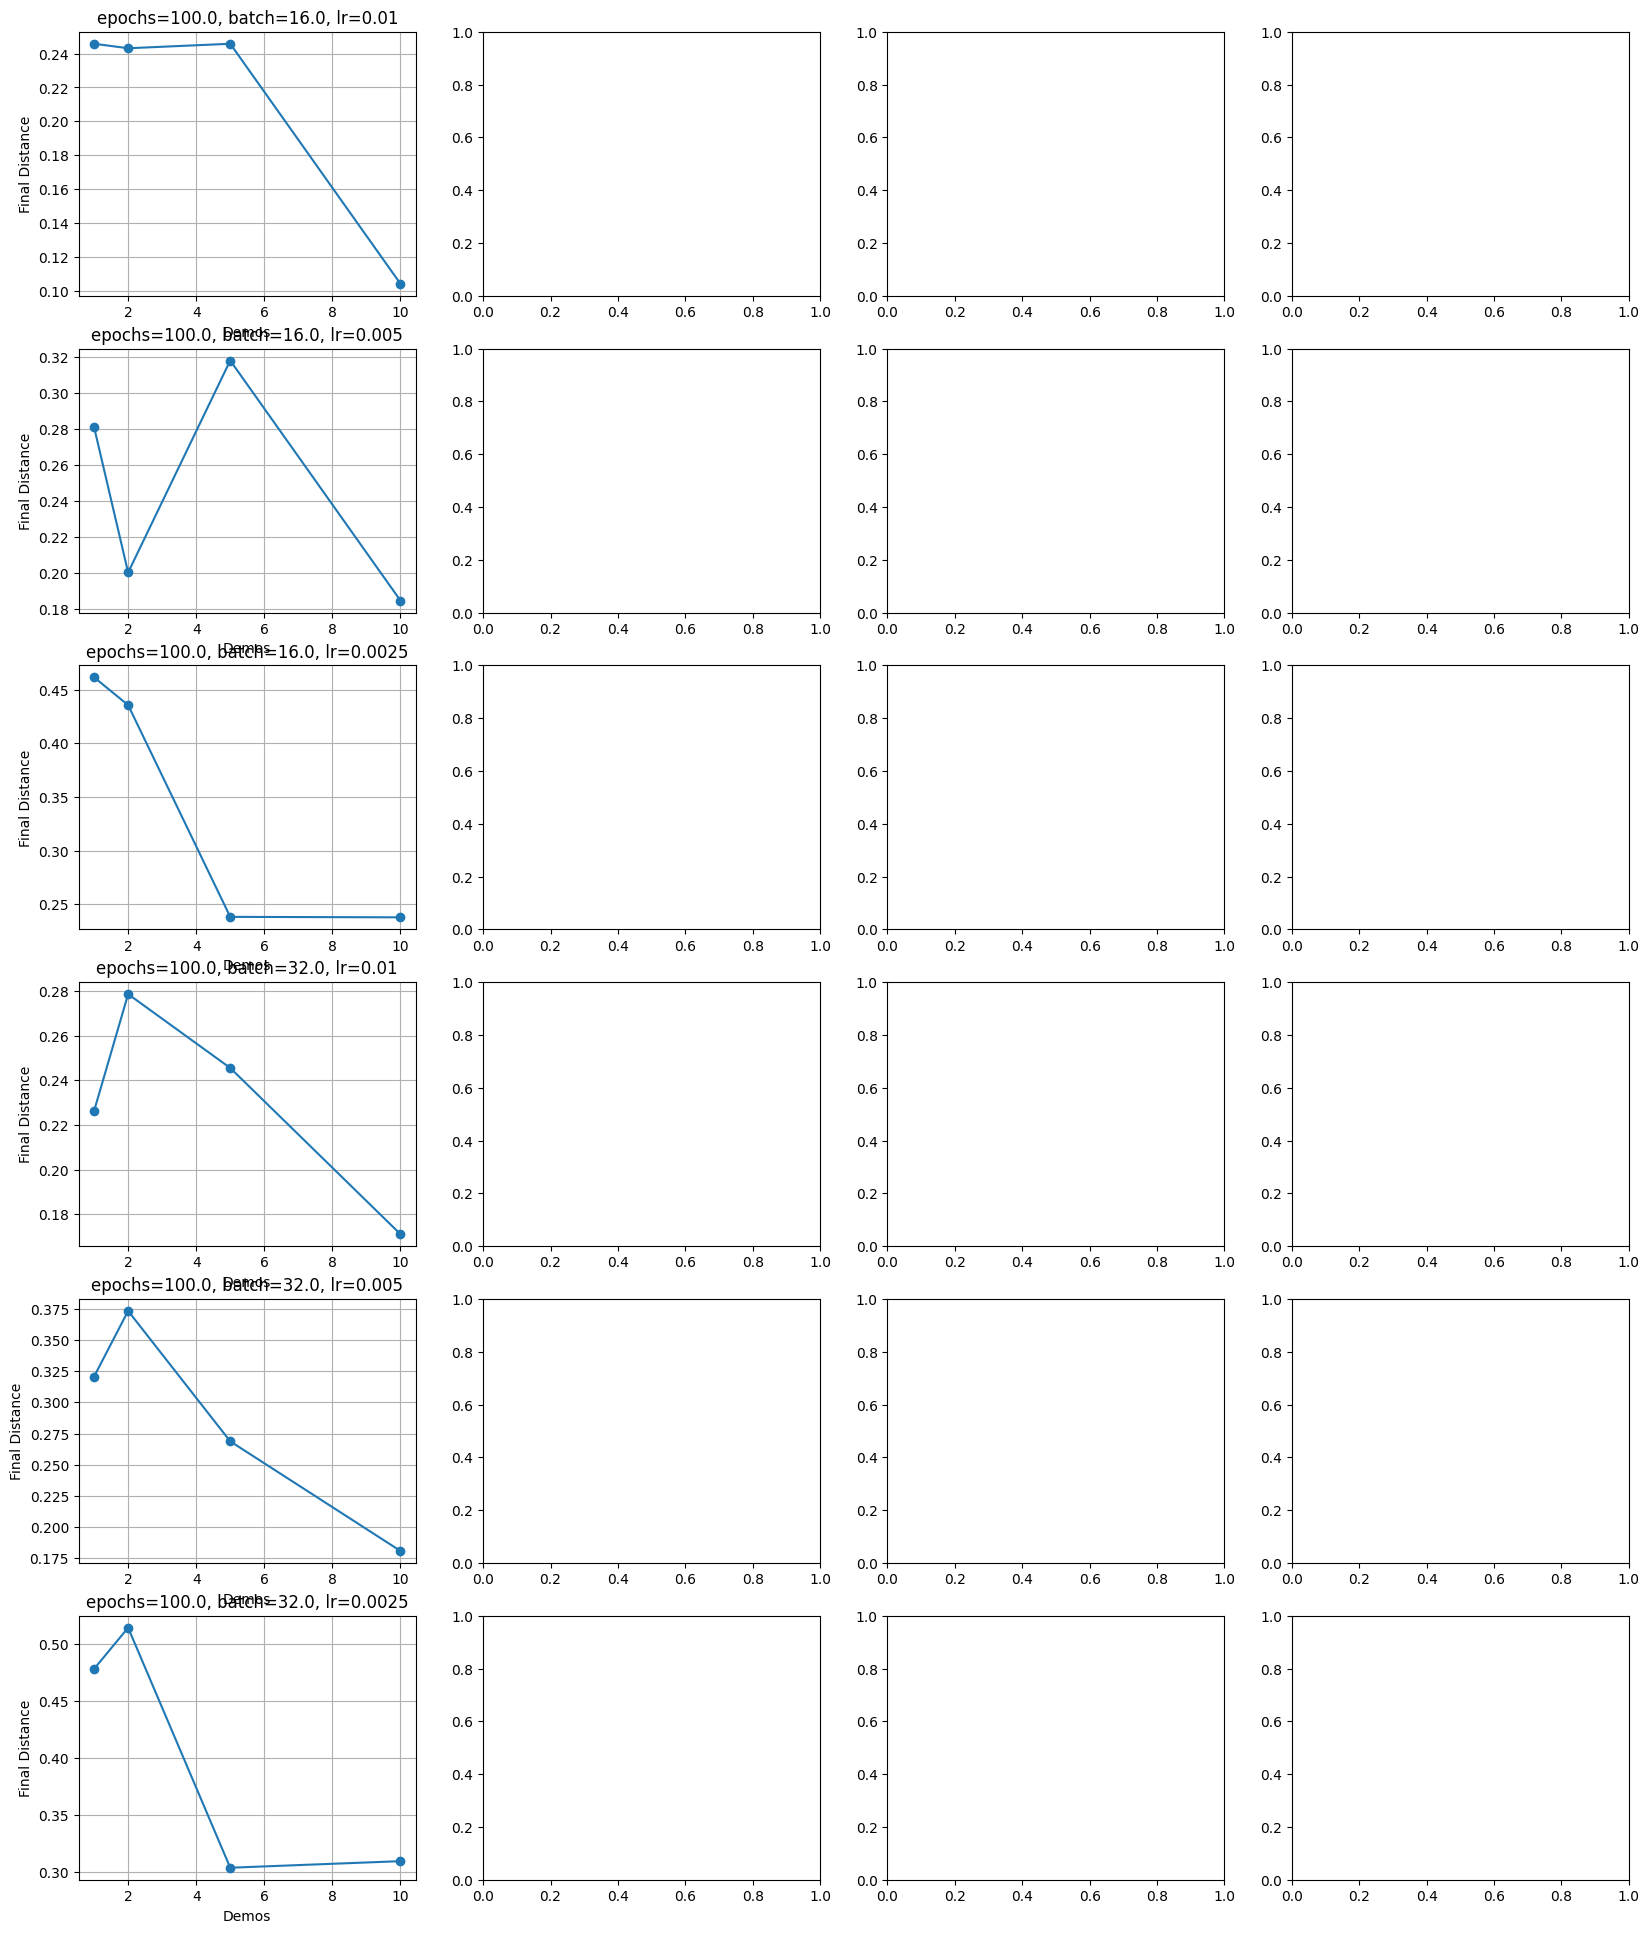

In [ ]:
# param_sets = df.drop(columns=['final_dist', 'demo_count']).drop_duplicates()
# print(f"{param_sets}")

# # Create plots
# n = len(param_sets)
# cols = 4
# rows = 6
# fig, axs = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)

# for idx, row in param_sets.iterrows():
#     ep, mb, lr = row['epoch'], row['minibatch_size'], row['learning_rate']
#     sub = df[(df['epoch'] == ep) & (df['minibatch_size'] == mb) & (df['learning_rate'] == lr)].sort_values('demo_count')

#     ax = axs[idx // cols, idx % cols]
#     ax.plot(sub['demo_count'], sub['final_dist'], marker='o')
#     ax.set_title(f"epochs={ep}, batch={mb}, lr={lr}")
#     ax.set_xlabel("Demos")
#     ax.set_ylabel("Final Distance")
#     ax.grid(True)

# # Remove any unused subplots
# for extra in range(n, rows * cols):
#     fig.delaxes(axs[extra // cols][extra % cols])

# plt.tight_layout()
# plt.show()